### Sketch some stuff

In [12]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mudata as md

from src.qpx import from_qpx


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Focus on getting the indices back from the adjacency matrix in varp

1. Generate an adjacency matrix and populate it with values

## Validation

In [13]:
# Check that the level is in the matrix bounds
def _validate_query_level(query_level: str, matrix_bounds: dict[str, tuple[int, int]]):
    if query_level not in matrix_bounds.keys():
        raise ValueError(f"Query level {query_level} not found in matrix bounds.")

# Check that the feature boundaries are consistent with the adjacency matrix size
def _validate_feature_bounds(feature_boundaries: dict[str, tuple[int, int]], adjacency_matrix: np.ndarray):
    total_range = sum(end - start for start, end in feature_boundaries.values())
    if total_range != adjacency_matrix.shape[0]:
        raise ValueError(f"Total range of feature boundaries ({total_range}) does not match adjacency matrix size ({adjacency_matrix.shape[0]}).")

# Check that the query feature is unique in the features lookup
def _check_unique_feature(features: np.ndarray, query: str):
    query_indices = np.where(features == query)[0]
    if len(query_indices) == 0:
        raise ValueError(f"Query '{query}' not found in features.")
    elif len(query_indices) > 1:
        raise ValueError(f"Query '{query}' found multiple times in features at indices {query_indices}.")

## Bound extraction

In [14]:
def _extract_feature_bounds_from_mudata(
    mdata: md.MuData,
) -> dict[str, tuple[int, int]]:
    bounds = {}
    current_index = 0
    for key, mod in mdata.mod.items():
        n_vars = mod.n_vars
        bounds[key] = (current_index, current_index + n_vars)
        current_index += n_vars
    return bounds

## Index translation

In [15]:
def feature_index_to_adjacency_index(
    query_feature_index: int,
    feature_level: str,
    feature_bounds: dict[str, tuple[int, int]],
) -> int:
    """Return actual index of query in adjacency matrix."""
    # Find the start of the requested feature level
    if feature_level not in feature_bounds:
        raise ValueError(f"Feature level '{feature_level}' not found in feature bounds")
    
    start, end = feature_bounds[feature_level]
    
    level_size = end - start
    if query_feature_index < 0 or query_feature_index >= level_size:
        raise ValueError(f"Query index {query_feature_index} out of range for level '{feature_level}' (size: {level_size})")
    
    return start + query_feature_index

def adjacency_index_to_feature_index(
    adjacency_index: int,
    feature_bounds: dict[str, tuple[int, int]],
) -> tuple[str, int]:
    """Return feature level and index of query in adjacency matrix."""
    for level, (start, end) in feature_bounds.items():
        if start <= adjacency_index < end:
            return level, adjacency_index - start
    raise ValueError(f"Adjacency index {adjacency_index} out of bounds for feature bounds.")

## Slicing operation

Assumes getting a unique numerical feature index for the current modality. Workflow would be

Loading precursor / protein / gene AnnData objects --> each of them has numerical feature indices --> creating an adjacency matrix from the concatenated indices + feature bounds

In [16]:
def slice_associated_features(
    query_feature_index: int,
    feature_level: str,
    feature_bounds: dict[str, tuple[int, int]],
    adjacency_matrix: np.ndarray,
) -> dict[str, list[int]]:
    """Convert a query feature index into a map of associated features across all levels.
    
    Works with both dense numpy arrays and sparse scipy matrices.
    
    Returns:
        Dictionary mapping feature level names to lists of feature indices that are
        connected to the query feature in the adjacency matrix.
    """
    from scipy import sparse
    
    # Convert query feature index to adjacency matrix index
    query_adjacency_index = feature_index_to_adjacency_index(
        query_feature_index=query_feature_index,
        feature_level=feature_level,
        feature_bounds=feature_bounds,
    )

    # Slice adjacency matrix to get associated features (where value is 1)
    # Handle both dense and sparse matrices
    if sparse.issparse(adjacency_matrix):
        # For sparse matrices, use getrow() to maintain 2D shape
        row = adjacency_matrix.getrow(query_adjacency_index)
        # Convert to dense 1D array for np.where
        row_dense = row.toarray().flatten()
        associated_adjacency_indices = np.where(row_dense == 1)[0]
    else:
        # For dense matrices, slice normally
        associated_adjacency_indices = np.where(adjacency_matrix[query_adjacency_index, :] == 1)[0]
    
    # Convert adjacency indices back to feature indices grouped by level
    associated_features = {level: [] for level in feature_bounds.keys()}
    
    for adj_idx in associated_adjacency_indices:
        level, feature_idx = adjacency_index_to_feature_index(
            adjacency_index=adj_idx,
            feature_bounds=feature_bounds,
        )
        associated_features[level].append(feature_idx)
    
    return associated_features

## Test with dummy adjacency matrix 

Not derived from mudata yet.

In [17]:
sides = ["GENE1", "GENE2", "PROTEIN1-1", "PROTEIN1-2", "PROTEIN2", "PRECURSOR1", "PRECURSOR2", "PRECURSOR3", "PRECURSOR4"]
am_df = pd.DataFrame({side: [0]*len(sides) for side in sides}, index=sides)

# gene1 maps to protein1-1 and protein1-2
am_df.loc["GENE1", "PROTEIN1-1"] = 1
am_df.loc["GENE1", "PROTEIN1-2"] = 1

# gene1 maps to precursor1, precursor2 and precursor3
am_df.loc["GENE1", "PRECURSOR1"] = 1
am_df.loc["GENE1", "PRECURSOR2"] = 1
am_df.loc["GENE1", "PRECURSOR3"] = 1

# protein1-1 maps to precursor1 and precursor2
am_df.loc["PROTEIN1-1", "PRECURSOR1"] = 1
am_df.loc["PROTEIN1-1", "PRECURSOR2"] = 1

# protein1-2 maps to precursor3
am_df.loc["PROTEIN1-2", "PRECURSOR3"] = 1

# gene2 maps to protein2
am_df.loc["GENE2", "PROTEIN2"] = 1

# protein2 maps to precursor4
am_df.loc["PROTEIN2", "PRECURSOR4"] = 1

# mirror that whole thing to make the matrix symmetric
am_df = am_df + am_df.T 

# every side maps to itself
for side in sides:
    am_df.loc[side, side] = 1

# Define the feature boundaries (we would get this from the constructor)
# In the real case we would generate the bounds from mudata directly
matrix_bounds = {"GENE": (0, 2), "PROTEIN": (2, 5), "PRECURSOR": (5, 9)}

In [18]:
# Test: get features associated with GENE1
slice_associated_features(
    query_feature_index=0,
    feature_level="GENE",
    feature_bounds=matrix_bounds,
    adjacency_matrix=am_df.values
)

{'GENE': [np.int64(0)],
 'PROTEIN': [np.int64(0), np.int64(1)],
 'PRECURSOR': [np.int64(0), np.int64(1), np.int64(2)]}

## Test with example MuData from GH

From https://github.com/orgs/scverse/projects/71/views/1?pane=issue&itemId=170549166&issue=scverse%7C202603_hackathon_proteomics%7C7

MuData object with n_obs × n_vars = 184 × 68769
  varp:	'feature_mapping'
  2 modalities
    precursors:	92 x 63273
      obs:	'run_accession', 'file_name', 'fraction', 'instrument', 'dissociation_method'
      var:	'sequence', 'peptidoform', 'charge', 'missed_cleavages', 'calculated_mz', 'anchor_protein', 'unique'
    proteins:	92 x 5496
      var:	'pg_names', 'gg_accessions', 'gg_names', 'molecular_weight', 'sequence_coverage', 'global_qvalue'

n_vars: 68769 (63273 precursors + 5496 proteins)


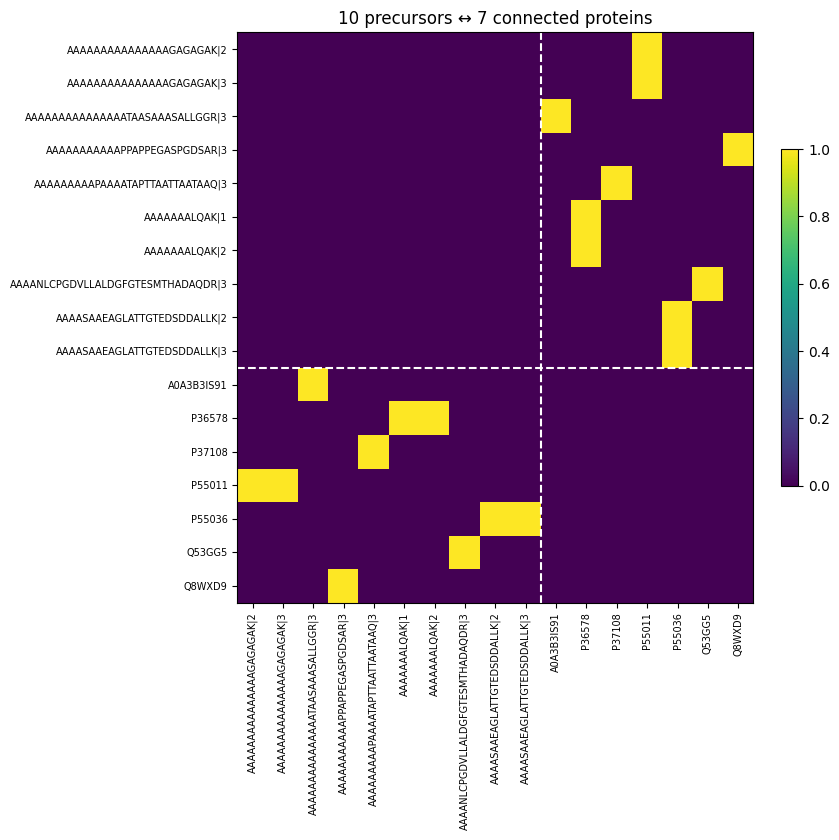

In [19]:
QPX_DIR = "/Users/julianuspfeuffer/Downloads/PXD020192/qpx"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mdata = from_qpx(QPX_DIR)

features = list(mdata.var_names)
print(mdata)
print(f"\nn_vars: {len(features)} ({len(mdata['precursors'].var_names)} precursors + {len(mdata['proteins'].var_names)} proteins)")

# Pick 10 precursors, then find the proteins they actually link to
n_prec = 10
prec_names = list(mdata["precursors"].var_names[:n_prec])

fm = mdata.varp["feature_mapping"]
var_pos = {v: i for i, v in enumerate(mdata.var_names)}
prot_offset = len(mdata["precursors"].var_names)

prot_idx_set = set()
for p in prec_names:
    row = fm.getrow(var_pos[p])
    _, cols = row.nonzero()
    prot_idx_set.update(c - prot_offset for c in cols if c >= prot_offset)

prot_names = list(mdata["proteins"].var_names[sorted(prot_idx_set)])
show_names = prec_names + prot_names
n_show = len(show_names)

show_idx = [var_pos[v] for v in show_names]
submat = fm[show_idx, :][:, show_idx].toarray()

fig, ax = plt.subplots(figsize=(max(8, n_show * 0.5), max(6, n_show * 0.5)))
im = ax.imshow(submat, cmap="viridis", aspect="auto")
ax.set_xticks(range(n_show))
ax.set_xticklabels(show_names, rotation=90, fontsize=7)
ax.set_yticks(range(n_show))
ax.set_yticklabels(show_names, fontsize=7)
ax.axvline(n_prec - 0.5, color="white", linewidth=1.5, linestyle="--")
ax.axhline(n_prec - 0.5, color="white", linewidth=1.5, linestyle="--")
ax.set_title(f"{n_prec} precursors ↔ {len(prot_names)} connected proteins")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()


In [20]:
# Extract feature bounds from the loaded MuData
feature_bounds = _extract_feature_bounds_from_mudata(mdata)
print("Feature bounds:", {k: v for k, v in feature_bounds.items()})

# Pick a precursor and find which protein it maps to
feature_level = "precursors"
query_feature_index = 0  # first precursor

result = slice_associated_features(
    query_feature_index=query_feature_index,
    feature_level=feature_level,
    feature_bounds=feature_bounds,
    adjacency_matrix=mdata.varp["feature_mapping"],
)

print(f"\nFeatures connected to precursor #{query_feature_index} ({mdata['precursors'].var_names[query_feature_index]}):")
for level, indices in result.items():
    names = (mdata[level].var_names[indices] if indices else [])
    print(f"  {level}: {list(names)}")


Feature bounds: {'precursors': (0, 63273), 'proteins': (63273, 68769)}

Features connected to precursor #0 (AAAAAAAAAAAAAAAGAGAGAK|2):
  precursors: []
  proteins: ['P55011']


## TODO:

In [21]:
import pytest
from scipy import sparse
import numpy as np
import pandas as pd

# Test fixtures
@pytest.fixture
def simple_adjacency_matrix():
    """Create a simple 6x6 adjacency matrix (2 proteins, 4 precursors)."""
    matrix = np.array([
        [1, 0, 1, 1, 0, 0],  # protein0 -> precursor0, precursor1
        [0, 1, 0, 1, 1, 1],  # protein1 -> precursor1, precursor2, precursor3
        [1, 0, 1, 0, 0, 0],  # precursor0 -> protein0
        [1, 1, 0, 1, 0, 0],  # precursor1 -> protein0, protein1
        [0, 1, 0, 0, 1, 0],  # precursor2 -> protein1
        [0, 1, 0, 0, 0, 1],  # precursor3 -> protein1
    ])
    return matrix

@pytest.fixture
def sparse_adjacency_matrix(simple_adjacency_matrix):
    return sparse.csr_matrix(simple_adjacency_matrix)

@pytest.fixture
def feature_bounds():
    return {
        "proteins": (0, 2),
        "precursors": (2, 6),
    }

# Test feature_index_to_adjacency_index
class TestFeatureToAdjacencyIndex:
    @pytest.mark.parametrize("query_idx,level,expected", [
        (0, "proteins", 0),
        (1, "proteins", 1),
        (0, "precursors", 2),
        (3, "precursors", 5),
    ])
    def test_valid_conversions(self, query_idx, level, expected, feature_bounds):
        result = feature_index_to_adjacency_index(query_idx, level, feature_bounds)
        assert result == expected

    def test_invalid_level(self, feature_bounds):
        with pytest.raises(ValueError, match="Feature level .* not found"):
            feature_index_to_adjacency_index(0, "invalid", feature_bounds)

    @pytest.mark.parametrize("query_idx,level", [
        (-1, "proteins"),
        (2, "proteins"),  # proteins only has indices 0,1
        (4, "precursors"),  # precursors only has indices 0-3
    ])
    def test_out_of_range_index(self, query_idx, level, feature_bounds):
        with pytest.raises(ValueError, match="out of range"):
            feature_index_to_adjacency_index(query_idx, level, feature_bounds)

# Test adjacency_index_to_feature_index
class TestAdjacencyToFeatureIndex:
    @pytest.mark.parametrize("adj_idx,expected_level,expected_idx", [
        (0, "proteins", 0),
        (1, "proteins", 1),
        (2, "precursors", 0),
        (5, "precursors", 3),
    ])
    def test_valid_conversions(self, adj_idx, expected_level, expected_idx, feature_bounds):
        level, idx = adjacency_index_to_feature_index(adj_idx, feature_bounds)
        assert level == expected_level
        assert idx == expected_idx

    @pytest.mark.parametrize("adj_idx", [-1, 6, 100])
    def test_out_of_bounds(self, adj_idx, feature_bounds):
        with pytest.raises(ValueError, match="out of bounds"):
            adjacency_index_to_feature_index(adj_idx, feature_bounds)

# Test slice_associated_features
class TestSliceAssociatedFeatures:
    @pytest.mark.parametrize("matrix_fixture", ["simple_adjacency_matrix", "sparse_adjacency_matrix"])
    def test_protein_to_precursors(self, matrix_fixture, feature_bounds, request):
        matrix = request.getfixturevalue(matrix_fixture)
        result = slice_associated_features(0, "proteins", feature_bounds, matrix)
        assert set(result["proteins"]) == {0}      # self
        assert set(result["precursors"]) == {0, 1} # connected precursors

    @pytest.mark.parametrize("matrix_fixture", ["simple_adjacency_matrix", "sparse_adjacency_matrix"])
    def test_shared_precursor(self, matrix_fixture, feature_bounds, request):
        matrix = request.getfixturevalue(matrix_fixture)
        # precursor1 (index 1) maps to both proteins
        result = slice_associated_features(1, "precursors", feature_bounds, matrix)
        assert set(result["proteins"]) == {0, 1}
        assert set(result["precursors"]) == {1}  # self

# Test edge cases
class TestEdgeCases:
    def test_empty_adjacency_matrix(self, feature_bounds):
        matrix = np.zeros((6, 6))
        result = slice_associated_features(0, "proteins", feature_bounds, matrix)
        for level_results in result.values():
            assert level_results == []

    def test_fully_connected_matrix(self, feature_bounds):
        matrix = np.ones((6, 6))
        result = slice_associated_features(0, "proteins", feature_bounds, matrix)
        assert set(result["proteins"]) == {0, 1}
        assert set(result["precursors"]) == {0, 1, 2, 3}


ModuleNotFoundError: No module named 'pytest'